# Daily Granularity Demand Forecasting
## Project: Product Placement Optimisation
## Student: Samikshya Baniya
## Student ID: 230360
## Module: ST6001CEM Individual Project

### Purpose
Refit the demand forecasting question from notebook 10 at daily rather than monthly granularity, and test the diagnosis made there: that the negative R squared (-2.377) came from too few observations, not from the wrong method.

### Input
data/processed/sales_data_cleaned.csv (read only), through `analysis/daily_forecast.py`

### Output
- `dashboard/artifacts/daily_revenue.csv`: the 304 day revenue series
- `dashboard/artifacts/daily_forecast_summary.json`: every figure reported here
- `reports/figures/chart25_daily_forecast.png`

### Why This Notebook Exists
Notebook 10 aggregated the record to eleven monthly observations, three of which formed the test set. Linear Regression scored R squared -2.377, worse than predicting the mean, and the notebook explained why: eleven points against a best-practice minimum of about thirty. The same eleven months contain 304 days with recorded sales. This notebook asks whether daily granularity fixes the problem.

**This is an extension, not a replacement.** The monthly result stays in the dissertation as a reported finding. Both are needed to tell the story of what went wrong and what happened when the obvious fix was tried.

### The rule that governs every comparison here
A daily error is never compared with a monthly error. They are different quantities. Every daily model is compared with the daily naive baselines on the same held-out days.

### Where the code lives
The models, the split and the metrics live in `analysis/daily_forecast.py`, so the verification sweep (`scripts/verify_thesis_numbers.py`) can refit them and check every number this notebook prints. The notebook runs that module and reads the results; it holds no second copy of the logic.

## Step 1: Load the module and build the daily series

The daily series is revenue summed per calendar date. 304 of the 308 calendar days between 17 July 2025 and 20 May 2026 have sales. The four missing days are closures, two of them festival days (Vijaya Dashami on 2 October and Bhai Tika on 23 October 2025).

In [1]:
import sys
from pathlib import Path

ROOT = Path.cwd().resolve()
if ROOT.name == 'notebooks':
    ROOT = ROOT.parent
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

import numpy as np
import pandas as pd
from IPython.display import Image, display

from analysis import daily_forecast as DF

daily = DF.build_daily_series()
DF.write_daily_series(daily)
daily = DF.load_daily_series()   # model exactly what the artifact stores

full = pd.date_range(daily['date'].min(), daily['date'].max(), freq='D')
missing = full.difference(daily['date'])

print(f"Trading days: {len(daily)} of {len(full)} calendar days")
print(f"Period: {daily['date'].min().date()} to {daily['date'].max().date()}")
print(f"Total revenue: Rs {daily['revenue'].sum():,.2f}")
print(f"Mean daily revenue: Rs {daily['revenue'].mean():,.2f}  (std Rs {daily['revenue'].std(ddof=0):,.0f})")
print("Days with no sales:")
for d in missing:
    print(f"  {d.date()} ({d.day_name()})")

Trading days: 304 of 308 calendar days
Period: 2025-07-17 to 2026-05-20
Total revenue: Rs 218,214,456.85
Mean daily revenue: Rs 717,810.71  (std Rs 133,628)
Days with no sales:
  2025-09-10 (Wednesday)
  2025-10-02 (Thursday)
  2025-10-23 (Thursday)
  2026-03-05 (Thursday)


## Step 2: Chronological split

The first 80 per cent of trading days train, the last 20 per cent test. A random split would place future days in the training set and leak information backwards, so it is not used.

In [2]:
train, test = DF.chronological_split(daily)
print(f"Train: {len(train)} days, {train['date'].min().date()} to {train['date'].max().date()}")
print(f"Test:  {len(test)} days, {test['date'].min().date()} to {test['date'].max().date()}")
print(f"Train mean revenue Rs {train['revenue'].mean():,.0f}, test mean Rs {test['revenue'].mean():,.0f}")

Train: 243 days, 2025-07-17 to 2026-03-20
Test:  61 days, 2026-03-21 to 2026-05-20
Train mean revenue Rs 717,775, test mean Rs 717,954


## Step 3: Day-of-week effects

Notebook 03 found Friday the highest revenue day, Wednesday the highest average basket, and Saturday, the Nepali weekly holiday, the quietest. At daily granularity the same pattern appears as a per-weekday mean. Note the nuance: Friday has the highest **total** because there are 44 Fridays against 43 Wednesdays in the record; on a per-day mean Wednesday and Friday are within one per cent of each other, and Saturday is clearly lowest. These effects enter the regression as day-of-week dummies.

In [3]:
dow = (daily.groupby('day_of_week')['revenue']
       .agg(mean_revenue='mean', days='count', total_revenue='sum')
       .reindex(DF.WEEKDAYS))
dow['mean_revenue'] = dow['mean_revenue'].round(0)
dow['total_revenue'] = dow['total_revenue'].round(0)
print(dow.to_string())
print()
print(f"Highest mean: {dow['mean_revenue'].idxmax()}   Lowest mean: {dow['mean_revenue'].idxmin()}   Highest total: {dow['total_revenue'].idxmax()}")

             mean_revenue  days  total_revenue
day_of_week                                   
Monday           722490.0    44     31789576.0
Tuesday          735129.0    44     32345694.0
Wednesday        750109.0    43     32254702.0
Thursday         703390.0    41     28838975.0
Friday           745545.0    44     32803986.0
Saturday         652803.0    44     28723344.0
Sunday           714959.0    44     31458180.0

Highest mean: Wednesday   Lowest mean: Saturday   Highest total: Friday


## Step 4: Fit and score every model

Two framings, both on the same 61 test days:

- **Fixed origin.** Train once, forecast every test day from the end of the training window. This is the "plan the next two months" question. Baselines: the last training day repeated (naive flat), the training mean repeated (historical mean), and the last training week repeated by weekday (seasonal naive). Models: Linear Regression with day-of-week dummies, the same with a linear trend, and Prophet with weekly seasonality.
- **Rolling one step ahead.** Each test day predicted from everything observed before it. This is the framing that "yesterday's value" belongs to. Baselines: naive persistence (yesterday), the expanding mean, and seasonal naive (same weekday last week). Models: Linear Regression refit every day, Prophet refit every day.

Prophet is fitted with weekly seasonality on, yearly and daily seasonality off, default trend flexibility, and is told nothing about festivals. Its point forecast is the MAP estimate, which is deterministic for identical input.

In [4]:
summary, preds, test = DF.run(daily, rolling_prophet=True, log=lambda s: None)

rows = []
for key, m in summary['models'].items():
    rows.append({'framing': m['framing'], 'model': m['name'],
                 'R2': round(m['r2'], 3), 'MAE (Rs)': round(m['mae']),
                 'RMSE (Rs)': round(m['rmse']), 'MAPE (%)': round(m['mape'], 2)})
table = pd.DataFrame(rows)
print("Fixed origin (61 test days forecast from the end of training)")
print(table[table.framing == 'fixed'].drop(columns='framing').to_string(index=False))
print()
print("Rolling one step ahead (each test day from everything before it)")
print(table[table.framing == 'rolling'].drop(columns='framing').to_string(index=False))

Fixed origin (61 test days forecast from the end of training)
                                       model     R2  MAE (Rs)  RMSE (Rs)  MAPE (%)
     Naive flat (last training day repeated) -0.000     74994     110685     12.10
    Historical mean (training mean repeated) -0.000     74959     110682     12.11
Seasonal naive (last training week repeated) -0.523    101417     136581     16.65
      Linear regression, day-of-week dummies -0.022     69473     111906     11.37
   Linear regression, day-of-week plus trend -0.078     76461     114922     12.74
                 Prophet, weekly seasonality -0.063     75114     114137     12.50

Rolling one step ahead (each test day from everything before it)
                                      model     R2  MAE (Rs)  RMSE (Rs)  MAPE (%)
      Naive persistence (yesterday's value) -1.600    119611     178482     18.17
  Expanding mean (all days observed so far) -0.004     75074     110886     12.12
    Seasonal naive (same weekday last week) -

## Step 5: Does any daily model beat naive persistence?

Yes, decisively, and that is the easy part of the answer. Naive persistence is a weak baseline for a series this noisy: day-to-day revenue swings by about 19 per cent of its level, so yesterday's value is a poor guide to today's. The demanding baseline is a constant at the training mean, and against that the best model gains only about 7 per cent.

In [5]:
v = summary['verdict']
best_r = v['rolling']['best_model']
best_f = v['fixed']['best_model']
print(f"Best rolling model: {summary['models'][best_r]['name']}")
for base in ('naive_persistence', 'seasonal_naive', 'expanding_mean'):
    imp = v['rolling'][f'vs_{base}'][best_r]
    print(f"  vs {summary['models'][base]['name']:44} MAE {imp['mae_change_pct']:+.1f}%")
print(f"Best fixed-origin model: {summary['models'][best_f]['name']}")
for base in ('naive_flat', 'historical_mean', 'seasonal_naive_fixed'):
    imp = v['fixed'][f'vs_{base}'][best_f]
    print(f"  vs {summary['models'][base]['name']:44} MAE {imp['mae_change_pct']:+.1f}%")
print()
fitted = ['linear_dow', 'linear_dow_trend', 'prophet_weekly', 'linear_dow_rolling', 'prophet_weekly_rolling']
best_r2 = max(summary['models'][k]['r2'] for k in fitted)
print(f"Highest R squared of any fitted model: {best_r2:.3f}")
print(f"Any model with positive R squared: {v['any_model_r2_positive_fixed'] or v['any_model_r2_positive_rolling']}")

Best rolling model: Linear regression, day-of-week, refit daily
  vs Naive persistence (yesterday's value)        MAE +41.6%
  vs Seasonal naive (same weekday last week)      MAE +28.6%
  vs Expanding mean (all days observed so far)    MAE +7.0%
Best fixed-origin model: Linear regression, day-of-week dummies
  vs Naive flat (last training day repeated)      MAE +7.4%
  vs Historical mean (training mean repeated)     MAE +7.3%
  vs Seasonal naive (last training week repeated) MAE +31.5%

Highest R squared of any fitted model: -0.015
Any model with positive R squared: False


## Step 6: Does Prophet still detect the Dashain peak?

At monthly granularity Prophet's fitted curve rose to the September point. At daily granularity, with weekly seasonality and the default trend flexibility, it does not: the fitted curve inside the Dashain window (22 September to 2 October 2025) sits at the same level as outside it, while the actual mean inside the window is about 40 per cent higher. Its fitted peak lands at the end of the training window, not at the festival.

The festival is a spike, not a trend, and Prophet's trend is deliberately stiff. Making it flexible enough to chase the spike (`changepoint_prior_scale` 0.5 instead of 0.05) does put the fitted peak inside the window, and it makes the held-out forecast substantially worse. Prophet can only see Dashain at daily granularity by overfitting, or by being told about it through a holiday regressor, which is not detection.

In [6]:
d = summary['dashain']
print("Prophet, specified settings:")
print(f"  actual peak day {d['actual_peak_day']} (Rs {d['actual_peak_revenue']:,.0f})")
print(f"  fitted peak day {d['fitted_peak_day']}, trend peak day {d['trend_peak_day']}")
print(f"  fitted mean inside window Rs {d['fitted_mean_inside_window']:,.0f} vs outside Rs {d['fitted_mean_outside_window']:,.0f}")
print(f"  actual mean inside window Rs {d['actual_mean_inside_window']:,.0f} vs outside Rs {d['actual_mean_outside_window']:,.0f}")
print(f"  peak inside the Dashain window: {d['fitted_peak_inside_window']}")
f = summary['prophet_sensitivity']
print("\nProphet, flexible trend (changepoint_prior_scale 0.5):")
print(f"  fitted peak day {f['dashain']['fitted_peak_day']}, inside window: {f['dashain']['fitted_peak_inside_window']}")
print(f"  fitted mean inside window Rs {f['dashain']['fitted_mean_inside_window']:,.0f}")
print(f"  held-out MAE Rs {f['mae']:,.0f} (default settings Rs {summary['models']['prophet_weekly']['mae']:,.0f}), R2 {f['r2']:.3f}")

Prophet, specified settings:
  actual peak day 2025-10-01 (Rs 1,386,057)
  fitted peak day 2026-03-18, trend peak day 2026-03-20
  fitted mean inside window Rs 716,206 vs outside Rs 717,894
  actual mean inside window Rs 988,038 vs outside Rs 706,175
  peak inside the Dashain window: False

Prophet, flexible trend (changepoint_prior_scale 0.5):
  fitted peak day 2025-09-24, inside window: True
  fitted mean inside window Rs 794,729
  held-out MAE Rs 102,647 (default settings Rs 75,114), R2 -0.521


## Step 7: Where the error comes from

Two test days, 13 and 14 April 2026, are Nepali New Year eve and day: 83 transactions on the 13th and the busiest day of the window on the 14th. They carry about half of the best model's squared error. This is reported as context. The headline metrics keep every day; the anomalies are part of what the store actually experiences.

In [7]:
es = summary['error_structure']
print(f"Days: {', '.join(es['days'])}  ({es['what']})")
print(f"Share of Linear Regression squared error: {es['share_of_linear_dow_sse_pct']:.1f}%")
print(f"Linear Regression MAE excluding them: Rs {es['linear_dow_mae_excluding_days']:,.0f}  (all days Rs {summary['models']['linear_dow']['mae']:,.0f})")
print(f"Linear Regression R2 excluding them: {es['linear_dow_r2_excluding_days']:.3f}")

Days: 2026-04-13, 2026-04-14  (Nepali New Year eve and day: 83 transactions on the 13th, the busiest test day on the 14th)
Share of Linear Regression squared error: 51.2%
Linear Regression MAE excluding them: Rs 56,873  (all days Rs 69,473)
Linear Regression R2 excluding them: -0.033


## Step 8: Chart 25

Saved reports\figures\chart25_daily_forecast.png and dashboard\artifacts\daily_forecast_summary.json


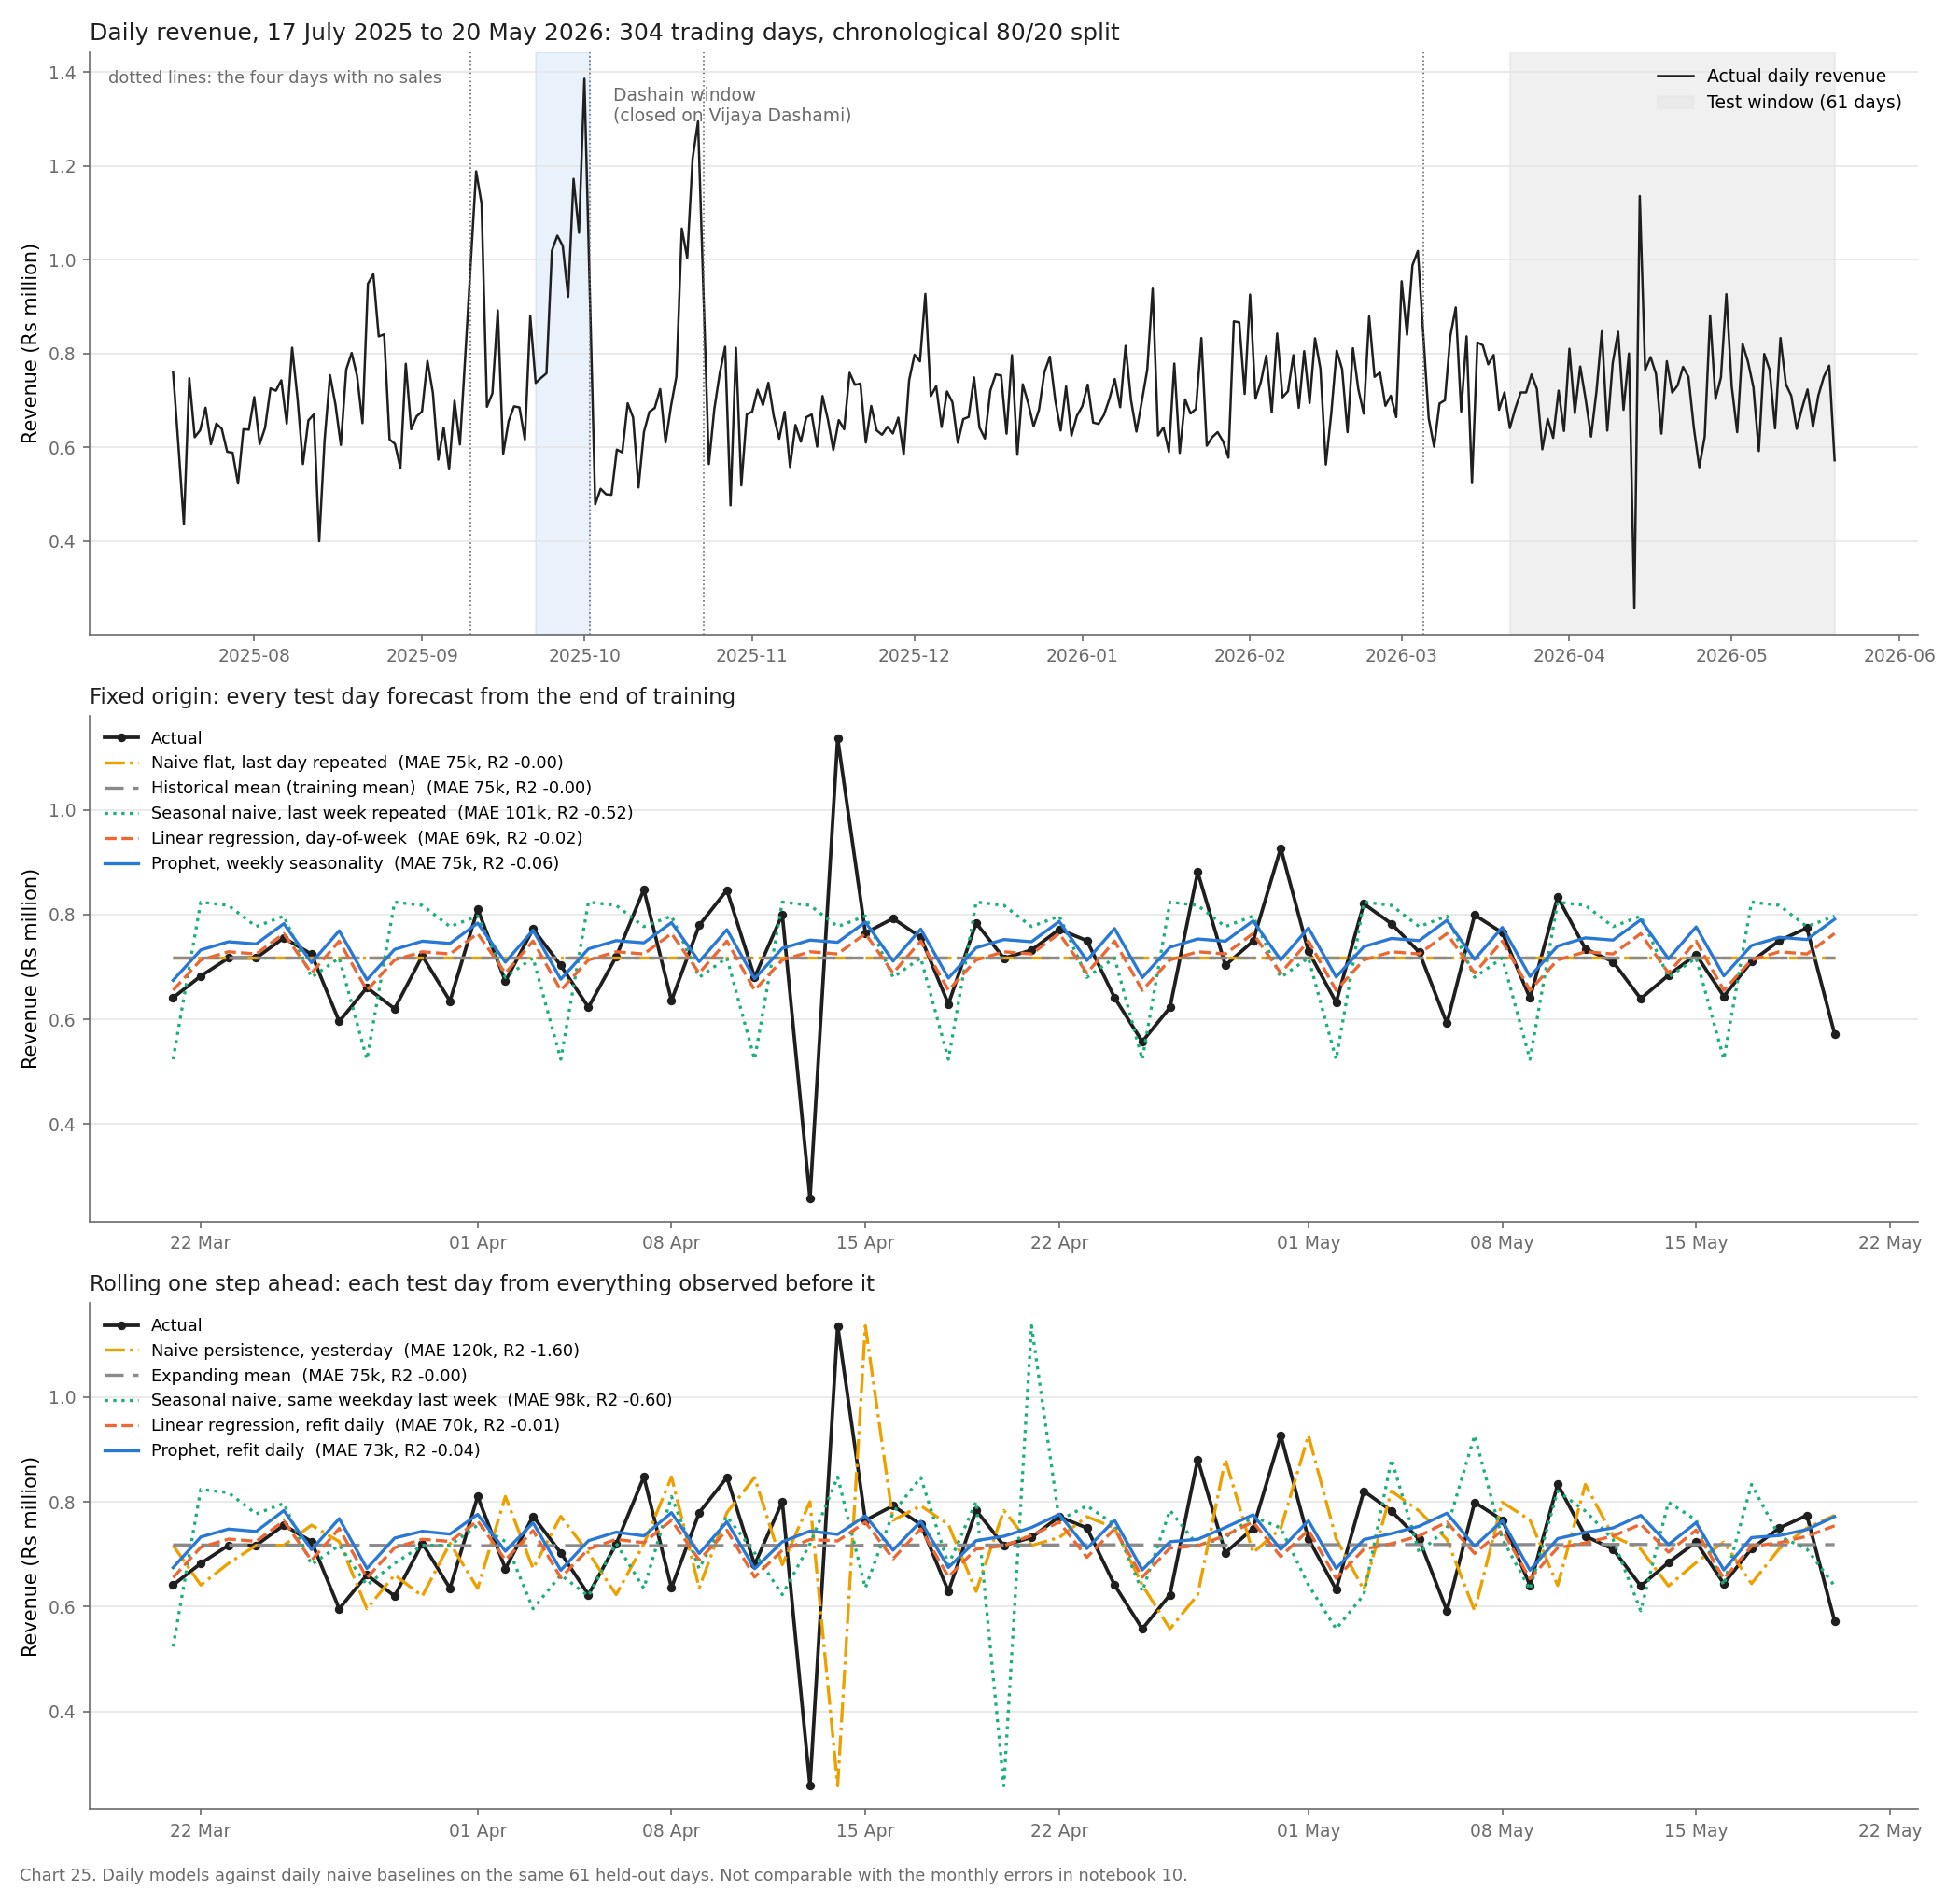

In [8]:
import json, os
fig_path = ROOT / 'reports' / 'figures' / DF.FIGURE_NAME
DF.draw_chart(daily, summary, preds, test, str(fig_path))
out_path = ROOT / 'dashboard' / 'artifacts' / DF.SUMMARY_ARTIFACT
with open(out_path, 'w', encoding='utf-8') as fh:
    json.dump(DF._serialisable(summary), fh, indent=2)
print(f"Saved {fig_path.relative_to(ROOT)} and {out_path.relative_to(ROOT)}")
display(Image(filename=str(fig_path)))

## Step 9: Honest verdict

**What daily granularity fixed.** The monthly regression was unstable because it had eight training points and three test points. At daily granularity every model is stable, the split is a proper 243/61 chronological hold-out, and every fitted model beats naive persistence by a wide margin (the best by about 42 per cent in MAE) and seasonal naive by about 29 per cent. A planning error of about 11 per cent MAPE is a usable number for a shop.

**What it did not fix.** No daily model, in either framing, reaches a positive R squared on the held-out days. The best fitted model explains no more of the day-to-day variation than the test window's own mean would, and beats a constant at the training mean by only about 7 per cent. Adding a trend makes the regression worse; Prophet does not beat the constant in the fixed-origin framing and beats it by about 2 per cent when refit daily. Prophet does not detect Dashain at daily granularity unless its trend is loosened enough to overfit.

**So is daily forecasting usable?** As a level-and-weekday planning rule, yes: the store's daily revenue sits on a stable mean of about Rs 718,000 with a Saturday dip and a Wednesday/Friday lift, and that rule forecasts to within about 11 per cent. As a model that explains variation, no. The predictable structure in this record is the mean and the weekday; the rest is festival spikes and noise that one Dashain season cannot teach a model to anticipate. The honest reading is that the monthly failure was real and daily granularity narrows it without removing it. What would remove it is more history: a second Dashain, so the festival becomes a pattern rather than a one-off.

### Key numbers
- 304 trading days, chronological split 243 train / 61 test (test from 21 March 2026)
- Naive persistence MAE Rs 119,611; best model (Linear Regression, day-of-week, refit daily) Rs 69,794, 41.6 per cent lower
- Historical mean MAE Rs 74,959; best fixed-origin model Rs 69,473, 7.3 per cent lower
- Highest R squared of any fitted model: -0.015. Nothing positive.
- Prophet, specified settings: no Dashain peak in the fitted curve; flexible trend finds it and forecasts worse (MAE Rs 102,647)
- Every one of these figures is checked by `scripts/verify_thesis_numbers.py`